# 01 — Data Exploration

Full checklist before preprocessing:
1. Load config
2. Inspect each dataset family (dims, coords, variables, resolution, NaNs, time coverage)
3. Check grid alignment across surface products (do they share the same lat/lon grid as GLORYS, or need regridding?)
4. Sanity-check Argo structure separately (point-based, not gridded)
5. Visual spot-check (land mask / missing data)
6. Summary report

In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
import yaml
import glob
from pathlib import Path
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
CONFIG_PATH = PROJECT_ROOT / "config" / "config.yaml"

with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

RAW_DIR = PROJECT_ROOT / cfg["paths"]["raw_data"]
region = cfg["region"]
target_depths = cfg["target_depths"]
expected_res = cfg["resolution"]

print("Config loaded:")
print(f"  Region: {region}")
print(f"  Expected resolution: {expected_res}")
print(f"  Target depths: {target_depths}")
print(f"  Raw data dir: {RAW_DIR}")

Config loaded:
  Region: {'latitude_min': 5, 'latitude_max': 30, 'longitude_min': 45, 'longitude_max': 105}
  Expected resolution: {'latitude': 0.25, 'longitude': 0.25}
  Target depths: [0, 5, 10, 20, 30, 50, 75, 100, 125, 150, 200, 300, 500, 700, 1000]
  Raw data dir: d:\DeepOceanAi\personal\data\raw


## 1. Inventory — what files do we actually have?

In [10]:
all_files = sorted(RAW_DIR.glob("*.nc"))
print(f"Found {len(all_files)} .nc files in {RAW_DIR}\n")

# Group by dataset family (prefix before the year)
from collections import defaultdict
families = defaultdict(list)
for f in all_files:
    # e.g. glorys_2021_01.nc -> family "glorys"
    #      sst_2021_01_06.nc -> family "sst"
    parts = f.stem.split("_")
    # find where the first 4-digit year token starts
    fam_tokens = []
    for tok in parts:
        if tok.isdigit() and len(tok) == 4:
            break
        fam_tokens.append(tok)
    family = "_".join(fam_tokens) if fam_tokens else f.stem
    families[family].append(f)

for fam, files in sorted(families.items()):
    print(f"{fam:20s} -> {len(files)} file(s)")
    for f in sorted(files):
        size_mb = f.stat().st_size / (1024 * 1024)
        print(f"    {f.name:35s} {size_mb:8.1f} MB")

Found 16 .nc files in d:\DeepOceanAi\personal\data\raw

argo                 -> 6 file(s)
    argo_2021_01.nc                          8.9 MB
    argo_2021_02.nc                          8.2 MB
    argo_2021_03.nc                          8.3 MB
    argo_2021_04.nc                          7.5 MB
    argo_2021_05.nc                         18.0 MB
    argo_2021_06.nc                         19.3 MB
glorys               -> 6 file(s)
    glorys_2021_01.nc                      449.1 MB
    glorys_2021_02.nc                      405.7 MB
    glorys_2021_03.nc                      449.1 MB
    glorys_2021_04.nc                      434.7 MB
    glorys_2021_05.nc                      449.1 MB
    glorys_2021_06.nc                      434.7 MB
ssh_currents         -> 1 file(s)
    ssh_currents_2021_01_06.nc             198.9 MB
sss                  -> 1 file(s)
    sss_2021_01_06.nc                       66.3 MB
sst                  -> 1 file(s)
    sst_2021_01_06.nc                      207

## 2. Generic dataset inspector

One function we reuse for every gridded dataset family (GLORYS, SSH/currents, SST, SSS, wind).
Reports: dims, coord ranges, variable list, resolution (lat/lon spacing), NaN fraction per variable,
and time coverage.

In [11]:
def inspect_gridded(path, lat_name="latitude", lon_name="longitude", time_name="time"):
    ds = xr.open_dataset(path)
    report = {"file": path.name}

    report["dims"] = dict(ds.dims)

    # coordinate names actually present (handle lat/lon vs latitude/longitude naming)
    lat_candidates = [c for c in ds.coords if c.lower() in ("lat", "latitude")]
    lon_candidates = [c for c in ds.coords if c.lower() in ("lon", "longitude")]
    time_candidates = [c for c in ds.coords if c.lower() in ("time",)]

    lat = ds[lat_candidates[0]].values if lat_candidates else None
    lon = ds[lon_candidates[0]].values if lon_candidates else None
    time = ds[time_candidates[0]].values if time_candidates else None

    if lat is not None:
        report["lat_range"] = (float(lat.min()), float(lat.max()))
        report["lat_res"] = float(np.round(np.median(np.diff(np.sort(lat))), 5)) if len(lat) > 1 else None
    if lon is not None:
        report["lon_range"] = (float(lon.min()), float(lon.max()))
        report["lon_res"] = float(np.round(np.median(np.diff(np.sort(lon))), 5)) if len(lon) > 1 else None
    if time is not None:
        report["time_range"] = (str(pd.Timestamp(time.min())), str(pd.Timestamp(time.max())))
        report["n_timesteps"] = len(time)

    report["variables"] = {}
    for var in ds.data_vars:
        da = ds[var]
        n_total = da.size
        n_nan = int(np.isnan(da.values).sum()) if np.issubdtype(da.dtype, np.floating) else None
        pct_nan = round(100 * n_nan / n_total, 1) if n_nan is not None else None
        report["variables"][var] = {
            "shape": da.shape,
            "dtype": str(da.dtype),
            "pct_nan": pct_nan,
        }

    ds.close()
    return report


def print_report(report):
    print(f"=== {report['file']} ===")
    print(f"  dims: {report['dims']}")
    if "lat_range" in report:
        print(f"  lat: {report['lat_range']}  (res ~{report.get('lat_res')})")
    if "lon_range" in report:
        print(f"  lon: {report['lon_range']}  (res ~{report.get('lon_res')})")
    if "time_range" in report:
        print(f"  time: {report['time_range']}  ({report['n_timesteps']} steps)")
    print("  variables:")
    for var, info in report["variables"].items():
        nan_flag = f"  <-- {info['pct_nan']}% NaN" if info["pct_nan"] and info["pct_nan"] > 0 else ""
        print(f"    {var:15s} shape={info['shape']} dtype={info['dtype']}{nan_flag}")
    print()

## 3. GLORYS — check every monthly file for consistent grid

In [12]:
glorys_files = sorted(RAW_DIR.glob("glorys_*.nc"))
glorys_reports = [inspect_gridded(f) for f in glorys_files]

for r in glorys_reports:
    print_report(r)

# Consistency check: do all months share the exact same lat/lon grid?
lat_ranges = set(r.get("lat_range") for r in glorys_reports)
lon_ranges = set(r.get("lon_range") for r in glorys_reports)
lat_res = set(r.get("lat_res") for r in glorys_reports)
lon_res = set(r.get("lon_res") for r in glorys_reports)

print("Consistency across GLORYS months:")
print(f"  Unique lat ranges: {lat_ranges}  {'OK' if len(lat_ranges)==1 else 'MISMATCH!'}")
print(f"  Unique lon ranges: {lon_ranges}  {'OK' if len(lon_ranges)==1 else 'MISMATCH!'}")
print(f"  Unique lat resolutions: {lat_res}  {'OK' if len(lat_res)==1 else 'MISMATCH!'}")
print(f"  Unique lon resolutions: {lon_res}  {'OK' if len(lon_res)==1 else 'MISMATCH!'}")

print(f"\nExpected resolution from config: {expected_res}")
print("NOTE: GLORYS native resolution is 0.083deg — if config says 0.25, ")
print("you still need to regrid/downsample in preprocessing; the raw files are native res.")

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15832\1353032947.py:5: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  report["dims"] = dict(ds.dims)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15832\1353032947.py:5: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  report["dims"] = dict(ds.dims)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15832\1353032947.py:5: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.

=== glorys_2021_01.nc ===
  dims: {'time': 31, 'depth': 35, 'latitude': 301, 'longitude': 721}
  lat: (5.0, 30.0)  (res ~0.08332999795675278)
  lon: (45.0, 105.0)  (res ~0.08333999663591385)
  time: ('2021-01-01 00:00:00', '2021-01-31 00:00:00')  (31 steps)
  variables:
    thetao          shape=(31, 35, 301, 721) dtype=float64  <-- 55.8% NaN

=== glorys_2021_02.nc ===
  dims: {'time': 28, 'depth': 35, 'latitude': 301, 'longitude': 721}
  lat: (5.0, 30.0)  (res ~0.08332999795675278)
  lon: (45.0, 105.0)  (res ~0.08333999663591385)
  time: ('2021-02-01 00:00:00', '2021-02-28 00:00:00')  (28 steps)
  variables:
    thetao          shape=(28, 35, 301, 721) dtype=float64  <-- 55.8% NaN

=== glorys_2021_03.nc ===
  dims: {'time': 31, 'depth': 35, 'latitude': 301, 'longitude': 721}
  lat: (5.0, 30.0)  (res ~0.08332999795675278)
  lon: (45.0, 105.0)  (res ~0.08333999663591385)
  time: ('2021-03-01 00:00:00', '2021-03-31 00:00:00')  (31 steps)
  variables:
    thetao          shape=(31, 35, 30

## 4. Surface products — SSH/currents, SST, SSS, surface winds

In [13]:
surface_families = {
    "ssh_currents": sorted(RAW_DIR.glob("ssh_currents_*.nc")),
    "sst": sorted(RAW_DIR.glob("sst_*.nc")),
    "sss": sorted(RAW_DIR.glob("sss_*.nc")),
    "wind_metopb": sorted(RAW_DIR.glob("wind_metopb_*.nc")),
}

surface_reports = {}
for fam, files in surface_families.items():
    if not files:
        print(f"[skip] no files found for family '{fam}'")
        continue
    print(f"\n########## {fam} ##########")
    reports = [inspect_gridded(f) for f in files]
    surface_reports[fam] = reports
    for r in reports:
        print_report(r)


########## ssh_currents ##########


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15832\1353032947.py:5: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  report["dims"] = dict(ds.dims)


=== ssh_currents_2021_01_06.nc ===
  dims: {'time': 181, 'latitude': 200, 'longitude': 480}
  lat: (5.0625, 29.9375)  (res ~0.125)
  lon: (45.0625, 104.9375)  (res ~0.125)
  time: ('2021-01-01 00:00:00', '2021-06-30 00:00:00')  (181 steps)
  variables:
    sla             shape=(181, 200, 480) dtype=float64  <-- 49.3% NaN
    ugos            shape=(181, 200, 480) dtype=float64  <-- 49.6% NaN
    vgos            shape=(181, 200, 480) dtype=float64  <-- 49.6% NaN


########## sst ##########


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15832\1353032947.py:5: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  report["dims"] = dict(ds.dims)


=== sst_2021_01_06.nc ===
  dims: {'time': 181, 'latitude': 500, 'longitude': 1200}
  lat: (5.025000095367432, 29.975000381469727)  (res ~0.05000000074505806)
  lon: (45.025001525878906, 104.9749984741211)  (res ~0.05000000074505806)
  time: ('2021-01-01 00:00:00', '2021-06-30 00:00:00')  (181 steps)
  variables:
    analysed_sst    shape=(181, 500, 1200) dtype=float64  <-- 50.1% NaN


########## sss ##########


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15832\1353032947.py:5: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  report["dims"] = dict(ds.dims)


=== sss_2021_01_06.nc ===
  dims: {'time': 181, 'depth': 1, 'latitude': 200, 'longitude': 480}
  lat: (5.0625, 29.9375)  (res ~0.125)
  lon: (45.0625, 104.9375)  (res ~0.125)
  time: ('2021-01-01 00:00:00', '2021-06-30 00:00:00')  (181 steps)
  variables:
    sos             shape=(181, 1, 200, 480) dtype=float64  <-- 50.3% NaN


########## wind_metopb ##########


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15832\1353032947.py:5: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  report["dims"] = dict(ds.dims)


=== wind_metopb_asc_2021_01_06.nc ===
  dims: {'time': 181, 'latitude': 200, 'longitude': 480}
  lat: (5.0625, 29.9375)  (res ~0.125)
  lon: (45.0625, 104.9375)  (res ~0.125)
  time: ('2021-01-01 00:00:00', '2021-06-30 00:00:00')  (181 steps)
  variables:
    eastward_wind   shape=(181, 200, 480) dtype=float64  <-- 81.7% NaN
    northward_wind  shape=(181, 200, 480) dtype=float64  <-- 81.7% NaN



## 5. Native resolution audit — every dataset vs. our SIH target grid

Important: the goal grid is NOT "whatever GLORYS's native grid is". Our target common grid
(from `config.yaml`, matching the SIH problem scope) is:

- **Region:** 5°N–30°N, 45°E–105°E
- **Resolution:** 0.25° × 0.25°
- **Cadence:** daily

Every dataset we downloaded (including GLORYS itself, which is native 0.083°) is at a
*different* native resolution than this target. This section documents each dataset's
native grid so preprocessing knows exactly what regridding work is needed for each one —
GLORYS included. Nothing here is treated as the reference grid; the config target is.

In [14]:
TARGET_LAT_RES = expected_res["latitude"]
TARGET_LON_RES = expected_res["longitude"]

print(f"Target grid (from config.yaml): {TARGET_LAT_RES}deg x {TARGET_LON_RES}deg, "
      f"region lat {region['latitude_min']}-{region['latitude_max']}, "
      f"lon {region['longitude_min']}-{region['longitude_max']}\n")

native_res_summary = []

# GLORYS itself
g = glorys_reports[0]
native_res_summary.append(("glorys", g.get("lat_res"), g.get("lon_res")))

# every surface product
for fam, reports in surface_reports.items():
    r = reports[0]
    native_res_summary.append((fam, r.get("lat_res"), r.get("lon_res")))

print(f"{'dataset':15s} {'native lat_res':15s} {'native lon_res':15s} {'matches target?'}")
print("-" * 65)
for fam, lat_r, lon_r in native_res_summary:
    matches = (lat_r == TARGET_LAT_RES) and (lon_r == TARGET_LON_RES)
    print(f"{fam:15s} {str(lat_r):15s} {str(lon_r):15s} {'YES' if matches else 'NEEDS REGRID to target'}")

print("\nEvery dataset flagged 'NEEDS REGRID to target' — including GLORYS — must be")
print("interpolated onto the common 0.25deg target grid in src/preprocessing/regridding.py.")
print("Do not treat GLORYS's native 0.083deg grid as the final target; it isn't.")

Target grid (from config.yaml): 0.25deg x 0.25deg, region lat 5-30, lon 45-105

dataset         native lat_res  native lon_res  matches target?
-----------------------------------------------------------------
glorys          0.08332999795675278 0.08333999663591385 NEEDS REGRID to target
ssh_currents    0.125           0.125           NEEDS REGRID to target
sst             0.05000000074505806 0.05000000074505806 NEEDS REGRID to target
sss             0.125           0.125           NEEDS REGRID to target
wind_metopb     0.125           0.125           NEEDS REGRID to target

Every dataset flagged 'NEEDS REGRID to target' — including GLORYS — must be
interpolated onto the common 0.25deg target grid in src/preprocessing/regridding.py.
Do not treat GLORYS's native 0.083deg grid as the final target; it isn't.


## 6. Argo — point-based structure (different from gridded products)

Argo data is NOT on a regular grid — each profile is a (lat, lon, time) point with
a vertical pressure series. Inspect separately.

In [15]:
argo_files = sorted(RAW_DIR.glob("argo_*.nc"))

def inspect_argo(path):
    ds = xr.open_dataset(path)
    n_points = ds.sizes.get("N_POINTS", 0)

    report = {"file": path.name, "n_points": n_points}

    if n_points > 0:
        # unique profiles: combination of lat/lon/time is a reasonable proxy pre-cleaning
        if all(v in ds.variables for v in ["LATITUDE", "LONGITUDE", "TIME"]):
            coords_df = pd.DataFrame({
                "lat": ds["LATITUDE"].values,
                "lon": ds["LONGITUDE"].values,
                "time": ds["TIME"].values,
            })
            report["approx_unique_profiles"] = coords_df.drop_duplicates().shape[0]

        if "PRES" in ds.variables:
            pres = ds["PRES"].values
            report["pressure_range"] = (float(np.nanmin(pres)), float(np.nanmax(pres)))

        if "TEMP" in ds.variables:
            temp = ds["TEMP"].values
            n_nan = int(np.isnan(temp).sum())
            report["temp_pct_nan"] = round(100 * n_nan / temp.size, 1) if temp.size else None

    ds.close()
    return report

if not argo_files:
    print("No argo_*.nc files found.")
else:
    for f in argo_files:
        r = inspect_argo(f)
        print(f"=== {r['file']} ===")
        print(f"  data points (N_POINTS): {r['n_points']}")
        if "approx_unique_profiles" in r:
            print(f"  approx unique profiles: {r['approx_unique_profiles']}")
        if "pressure_range" in r:
            print(f"  pressure range: {r['pressure_range']} dbar")
        if "temp_pct_nan" in r:
            print(f"  TEMP % NaN: {r['temp_pct_nan']}")
        print()

=== argo_2021_01.nc ===
  data points (N_POINTS): 41282
  approx unique profiles: 188
  pressure range: (0.0, 1000.719970703125) dbar
  TEMP % NaN: 0.0

=== argo_2021_02.nc ===
  data points (N_POINTS): 37986
  approx unique profiles: 167
  pressure range: (0.0, 1000.7000122070312) dbar
  TEMP % NaN: 0.0

=== argo_2021_03.nc ===
  data points (N_POINTS): 38465
  approx unique profiles: 183
  pressure range: (0.0, 1000.739990234375) dbar
  TEMP % NaN: 0.0

=== argo_2021_04.nc ===
  data points (N_POINTS): 35014
  approx unique profiles: 173
  pressure range: (0.07000000029802322, 1000.739990234375) dbar
  TEMP % NaN: 0.0

=== argo_2021_05.nc ===
  data points (N_POINTS): 84187
  approx unique profiles: 241
  pressure range: (0.0, 1000.780029296875) dbar
  TEMP % NaN: 0.0

=== argo_2021_06.nc ===
  data points (N_POINTS): 90119
  approx unique profiles: 242
  pressure range: (0.0, 1000.7999877929688) dbar
  TEMP % NaN: 0.0



## 7. Visual spot-check

Plot one GLORYS temperature slice (surface + one deeper level) to eyeball the land mask
and confirm the region bounds look right — this catches orientation/index bugs that
summary stats can miss.

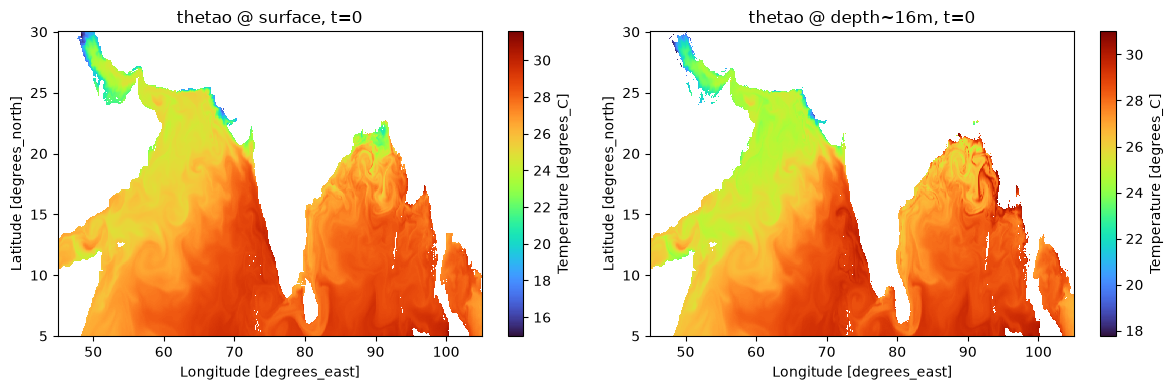

In [16]:
sample = xr.open_dataset(glorys_files[0])
var_name = "thetao"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

surface = sample[var_name].isel(time=0, depth=0)
surface.plot(ax=axes[0], cmap="turbo")
axes[0].set_title(f"{var_name} @ surface, t=0")

# pick a mid-depth level if available
depth_dim = "depth" if "depth" in sample.dims else None
if depth_dim and sample.sizes[depth_dim] > 5:
    mid_idx = min(10, sample.sizes[depth_dim] - 1)
    deep = sample[var_name].isel(time=0, depth=mid_idx)
    deep.plot(ax=axes[1], cmap="turbo")
    depth_val = float(sample["depth"].isel(depth=mid_idx).values)
    axes[1].set_title(f"{var_name} @ depth~{depth_val:.0f}m, t=0")

plt.tight_layout()
plt.show()

sample.close()

## 8. Summary checklist

In [17]:
print("=" * 60)
print("EXPLORATION SUMMARY")
print("=" * 60)

print(f"\nGLORYS: {len(glorys_files)} monthly files")
print(f"  Grid consistent across months: {len(lat_ranges)==1 and len(lon_ranges)==1}")

print(f"\nArgo: {len(argo_files)} monthly files")

print(f"\nTarget grid (config.yaml): {TARGET_LAT_RES}deg x {TARGET_LON_RES}deg, "
      f"region lat {region['latitude_min']}-{region['latitude_max']}, "
      f"lon {region['longitude_min']}-{region['longitude_max']}")

print("\nNative resolution vs. target grid:")
for fam, lat_r, lon_r in native_res_summary:
    matches = (lat_r == TARGET_LAT_RES) and (lon_r == TARGET_LON_RES)
    print(f"  {fam:15s} {'OK' if matches else 'NEEDS REGRID'}  (native res: {lat_r}, {lon_r})")

print("\nNext steps for src/preprocessing/:")
print("  1. Regrid every gridded dataset (GLORYS included) onto the common 0.25deg target grid")
print("  2. Convert Argo PRES -> standard depth levels (config.target_depths)")
print("  3. Pair each Argo profile with the nearest target-grid cell + timestamp")
print("  4. Handle land-mask NaNs consistently across all inputs before creating patches")

EXPLORATION SUMMARY

GLORYS: 6 monthly files
  Grid consistent across months: True

Argo: 6 monthly files

Target grid (config.yaml): 0.25deg x 0.25deg, region lat 5-30, lon 45-105

Native resolution vs. target grid:
  glorys          NEEDS REGRID  (native res: 0.08332999795675278, 0.08333999663591385)
  ssh_currents    NEEDS REGRID  (native res: 0.125, 0.125)
  sst             NEEDS REGRID  (native res: 0.05000000074505806, 0.05000000074505806)
  sss             NEEDS REGRID  (native res: 0.125, 0.125)
  wind_metopb     NEEDS REGRID  (native res: 0.125, 0.125)

Next steps for src/preprocessing/:
  1. Regrid every gridded dataset (GLORYS included) onto the common 0.25deg target grid
  2. Convert Argo PRES -> standard depth levels (config.target_depths)
  3. Pair each Argo profile with the nearest target-grid cell + timestamp
  4. Handle land-mask NaNs consistently across all inputs before creating patches
